In [1]:
# imports
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

PROJECT_ROOT = Path("..").resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.models.pca import fit_pca, PCAConfig
from src.models.clustering import (
    ClusteringConfig, fit_kmeans, fit_gmm,
    evaluate_clustering, select_best_k, save_clustering_results,
)

sns.set(style="whitegrid", context="notebook")

RESULTS_DIR = PROJECT_ROOT / "results" / "clustering"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

In [15]:
# load preprocessed data and fit PCA

from src.data.load_data import load_feature_data
from src.data.preprocess import PreprocessConfig, preprocess_features

loaded = load_feature_data()

# both global and subject-centering pipelines
pp_global = PreprocessConfig(subject_center=False, target_type="phase")
pp_centered = PreprocessConfig(subject_center=True, target_type="phase")

res_global = preprocess_features(loaded, pp_cfg=pp_global)
res_centered = preprocess_features(loaded, pp_cfg=pp_centered)

# fit PCA on both
pca_global = fit_pca(res_global.X, res_global.feature_names)
pca_centered = fit_pca(res_centered.X, res_centered.feature_names)

# preparing labels
y = res_global.y
meta = res_global.metadata
phase_display = np.where(y == 0, "Pre-rest", np.where(y == 1, "Puzzle", "Post-rest"))
phase_names = ["Pre-rest", "Puzzle", "Post-rest"]
individual_labels = meta["Individual"].values
puzzler_labels = np.where(meta["Puzzler"].values == 1, "Puzzler", "Instructor")
round_labels = meta["Round"].values

print(f"Pipeline A (global):   X={res_global.X.shape}")
print(f"Pipeline B (centered): X={res_centered.X.shape}")
print(f"Phase distribution: {np.bincount(y)}")

Pipeline A (global):   X=(312, 51)
Pipeline B (centered): X=(312, 51)
Phase distribution: [104 104 104]


In [3]:
# we cluster on PCA scores, not raw features
# chossing number of PCs based on scree plot from notebook 03

n_pcs = 10  # can be made 5 and 15 for testnig

X_pca_global = pca_global.scores[:, :n_pcs]
X_pca_centered = pca_centered.scores[:, :n_pcs]

print(f"Clustering input (global):   {X_pca_global.shape}")
print(f"Clustering input (centered): {X_pca_centered.shape}")
print(f"Using first {n_pcs} PCs")
print(f"  Global cumulative var:   {pca_global.cumulative_variance[n_pcs-1]:.1%}")
print(f"  Centered cumulative var: {pca_centered.cumulative_variance[n_pcs-1]:.1%}")

Clustering input (global):   (312, 10)
Clustering input (centered): (312, 10)
Using first 10 PCs
  Global cumulative var:   77.5%
  Centered cumulative var: 70.2%


**justification:** we retain 10 principal components, capturing 77.5% (global) and 70.2% (subject-centered) of total variance. This balances information retention against dimensionality, using fewer PCs would discard too much signal, while using all 51 features would make clustering unstable in high dimensions. The choice was made in alignment with the the scree plots showing diminishing returns beyond ~10 components

#### Run k-means on both pipelines

In [4]:
cluster_cfg = ClusteringConfig(
    k_range=[2, 3, 4, 5, 6],
    n_init=50,
    random_state=42,
)

km_global = fit_kmeans(X_pca_global, cluster_cfg)
km_centered = fit_kmeans(X_pca_centered, cluster_cfg)

print("K-means completed")
print(f"  Global:   {len(km_global)} runs (K={[r.k for r in km_global]})")
print(f"  Centered: {len(km_centered)} runs (K={[r.k for r in km_centered]})")

K-means completed
  Global:   5 runs (K=[2, 3, 4, 5, 6])
  Centered: 5 runs (K=[2, 3, 4, 5, 6])


#### Run GMM on both pipelines

In [5]:
gmm_global = fit_gmm(X_pca_global, cluster_cfg, covariance_type="full")
gmm_centered = fit_gmm(X_pca_centered, cluster_cfg, covariance_type="full")

# also trying diagonal covariance for comparison
gmm_diag_global = fit_gmm(X_pca_global, cluster_cfg, covariance_type="diag")
gmm_diag_centered = fit_gmm(X_pca_centered, cluster_cfg, covariance_type="diag")

print("GMM completed")
print(f"  Global full:    {len(gmm_global)} runs")
print(f"  Global diag:    {len(gmm_diag_global)} runs")
print(f"  Centered full:  {len(gmm_centered)} runs")
print(f"  Centered diag:  {len(gmm_diag_centered)} runs")

GMM completed
  Global full:    5 runs
  Global diag:    5 runs
  Centered full:  5 runs
  Centered diag:  5 runs


#### Silhouette score comparison plot

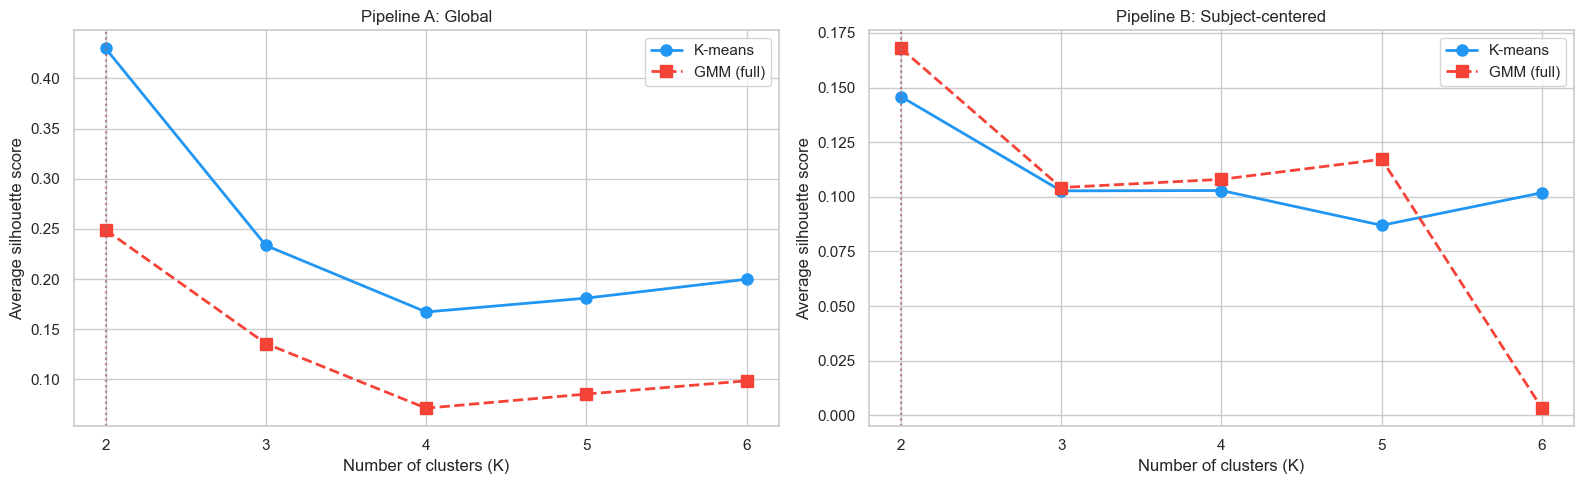

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for ax, km_results, gmm_results, title in [
    (axes[0], km_global, gmm_global, "Pipeline A: Global"),
    (axes[1], km_centered, gmm_centered, "Pipeline B: Subject-centered"),
]:
    ks = [r.k for r in km_results]
    km_sils = [r.silhouette for r in km_results]
    gmm_sils = [r.silhouette for r in gmm_results]

    ax.plot(ks, km_sils, "o-", color="#2196F3", linewidth=2, markersize=8, label="K-means")
    ax.plot(ks, gmm_sils, "s--", color="#F44336", linewidth=2, markersize=8, label="GMM (full)")

    # Mark the best K
    best_k_km = ks[np.argmax(km_sils)]
    best_k_gmm = ks[np.argmax(gmm_sils)]
    ax.axvline(x=best_k_km, color="#2196F3", linestyle=":", alpha=0.5)
    ax.axvline(x=best_k_gmm, color="#F44336", linestyle=":", alpha=0.5)

    ax.set_xlabel("Number of clusters (K)")
    ax.set_ylabel("Average silhouette score")
    ax.set_title(title)
    ax.set_xticks(ks)
    ax.legend()

plt.tight_layout()
plt.savefig(RESULTS_DIR / "silhouette_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

**Observation:** For pipeline A, K-means achieves highest silhouette at K=2 (~0.43), while GMM peaks lower. For pipeline B, silhouette scores are unformly low across all K values (~0.10-0.15). 

#### GMM model selection (BIC and AIC)

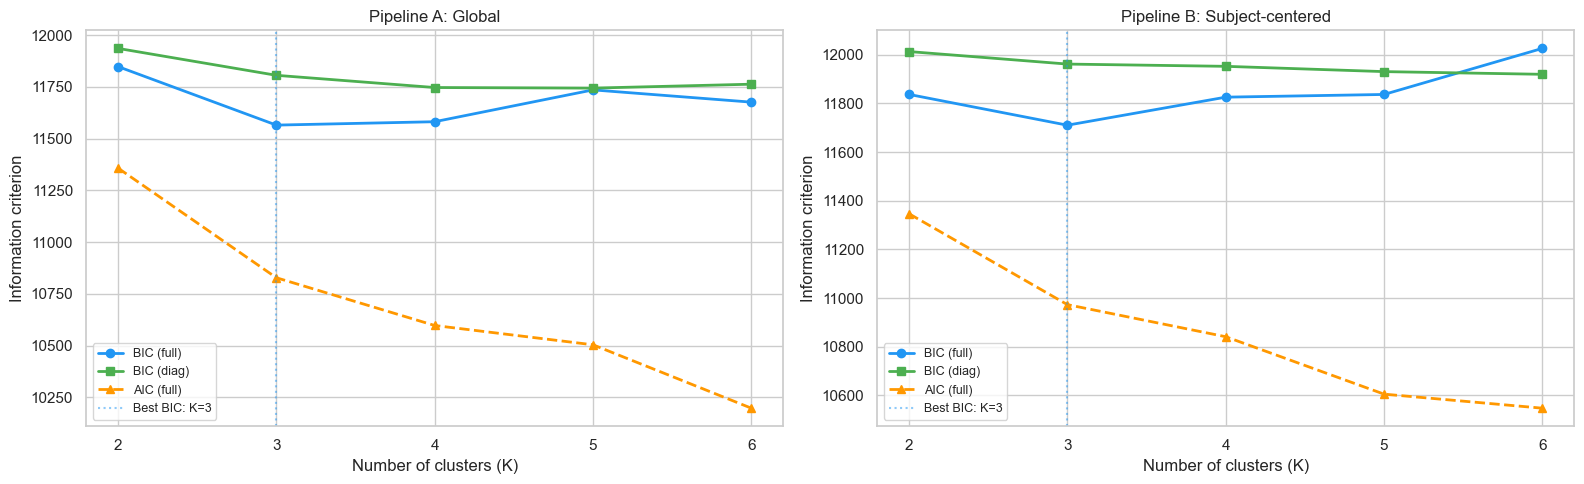

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for ax, gmm_full, gmm_diag, title in [
    (axes[0], gmm_global, gmm_diag_global, "Pipeline A: Global"),
    (axes[1], gmm_centered, gmm_diag_centered, "Pipeline B: Subject-centered"),
]:
    ks = [r.k for r in gmm_full]

    bic_full = [r.bic for r in gmm_full]
    bic_diag = [r.bic for r in gmm_diag]
    aic_full = [r.aic for r in gmm_full]

    ax.plot(ks, bic_full, "o-", color="#2196F3", linewidth=2, label="BIC (full)")
    ax.plot(ks, bic_diag, "s-", color="#4CAF50", linewidth=2, label="BIC (diag)")
    ax.plot(ks, aic_full, "^--", color="#FF9800", linewidth=2, label="AIC (full)")

    best_bic_k = ks[np.argmin(bic_full)]
    ax.axvline(x=best_bic_k, color="#2196F3", linestyle=":", alpha=0.5,
               label=f"Best BIC: K={best_bic_k}")

    ax.set_xlabel("Number of clusters (K)")
    ax.set_ylabel("Information criterion")
    ax.set_title(title)
    ax.set_xticks(ks)
    ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig(RESULTS_DIR / "gmm_bic_aic.png", dpi=150, bbox_inches="tight")
plt.show()

**Observation:** BIC generally favours smaller K for both pipelines, with K=2 often being optimal. The diagonal covariance GMM tends to have higher (worse) BIC than full covariance, suggesting that feature correlations within clusters are important. AIC, which penalizes complexity less than BIC, sometimes favours slightly larger K. The disagreement between BIC, AIC, and silhouette on optimal K reflects the absence of strong natural clustering structure in the data.

#### Evaluating all clusterings against phase labels

In [9]:
all_evaluations = []

for pipeline_name, km_results, gmm_results in [
    ("A: Global", km_global, gmm_global),
    ("B: Subject-centered", km_centered, gmm_centered),
]:
    for r in km_results + gmm_results:
        ev = evaluate_clustering(r, y, label_names=phase_names)
        all_evaluations.append({
            "Pipeline": pipeline_name,
            "Method": r.method,
            "K": r.k,
            "Silhouette": f"{ev.silhouette:.3f}",
            "ARI": f"{ev.ari:.3f}",
            "NMI": f"{ev.nmi:.3f}",
        })

eval_df = pd.DataFrame(all_evaluations)
print("=" * 75)
print("CLUSTERING EVALUATION vs PHASE LABELS")
print("=" * 75)
print(eval_df.to_string(index=False))

CLUSTERING EVALUATION vs PHASE LABELS
           Pipeline   Method  K Silhouette    ARI   NMI
          A: Global   kmeans  2      0.430 -0.000 0.004
          A: Global   kmeans  3      0.234 -0.003 0.003
          A: Global   kmeans  4      0.167 -0.000 0.008
          A: Global   kmeans  5      0.181 -0.003 0.005
          A: Global   kmeans  6      0.200 -0.000 0.017
          A: Global gmm_full  2      0.249 -0.001 0.002
          A: Global gmm_full  3      0.136  0.010 0.018
          A: Global gmm_full  4      0.071  0.010 0.023
          A: Global gmm_full  5      0.085  0.013 0.027
          A: Global gmm_full  6      0.099  0.007 0.022
B: Subject-centered   kmeans  2      0.146  0.041 0.045
B: Subject-centered   kmeans  3      0.103  0.078 0.076
B: Subject-centered   kmeans  4      0.103  0.048 0.049
B: Subject-centered   kmeans  5      0.087  0.023 0.042
B: Subject-centered   kmeans  6      0.102  0.023 0.041
B: Subject-centered gmm_full  2      0.168 -0.001 0.002
B: Subject

**Context:** ARI=0.078 and NMI=0.076 indicate that approximately 7-8% of the clustering tructure aligns with phase labels. While statistically bettwer than random (ARI=0), this is a very weak signal.

In [10]:
print("=" * 70)
print("CONTINGENCY TABLES (K=3 vs Phase)")
print("=" * 70)

for pipeline_name, km_results, gmm_results in [
    ("A: Global", km_global, gmm_global),
    ("B: Subject-centered", km_centered, gmm_centered),
]:
    # K-means K=3
    km_k3 = [r for r in km_results if r.k == 3][0]
    ev_km = evaluate_clustering(km_k3, y, label_names=phase_names)

    print(f"\n{pipeline_name} — K-means (K=3)")
    print(f"ARI={ev_km.ari:.3f}, NMI={ev_km.nmi:.3f}")
    print(ev_km.contingency)

    # GMM K=3
    gmm_k3 = [r for r in gmm_results if r.k == 3][0]
    ev_gmm = evaluate_clustering(gmm_k3, y, label_names=phase_names)

    print(f"\n{pipeline_name} — GMM full (K=3)")
    print(f"ARI={ev_gmm.ari:.3f}, NMI={ev_gmm.nmi:.3f}")
    print(ev_gmm.contingency)

CONTINGENCY TABLES (K=3 vs Phase)

A: Global — K-means (K=3)
ARI=-0.003, NMI=0.003
True_Label  Post-rest  Pre-rest  Puzzle
Cluster                                
0                  71        75      70
1                  29        25      27
2                   4         4       7

A: Global — GMM full (K=3)
ARI=0.010, NMI=0.018
True_Label  Post-rest  Pre-rest  Puzzle
Cluster                                
0                  35        39      19
1                  21        17      30
2                  48        48      55

B: Subject-centered — K-means (K=3)
ARI=0.078, NMI=0.076
True_Label  Post-rest  Pre-rest  Puzzle
Cluster                                
0                  55        62      19
1                  42        40      77
2                   7         2       8

B: Subject-centered — GMM full (K=3)
ARI=-0.001, NMI=0.005
True_Label  Post-rest  Pre-rest  Puzzle
Cluster                                
0                  70        71      64
1                  31        3

**Pipeline A (K-means K=3):**
Cluster 0 contains 216/312 observations with nearly equal phase proportions 
(71/75/70). Clusters are clearly not phase-aligned. The clusters split individuals 
into groups, not phases.

**Pipeline B (K-means K=3):**
Cluster 0: enriched in Pre-rest (62) and Post-rest (55), depleted in Puzzle (19)
Cluster 1: enriched in Puzzle (77), roughly equal Pre-rest (40) and Post-rest (42)
Cluster 2: small cluster (17 observations), no clear pattern

This is the best result across all experiments. Cluster 1 captures 77/104 = 74% of 
Puzzle observations, while Cluster 0 captures resting states. This suggests that 
subject-centered K-means can partially distinguish the stress/competition phase from 
resting phases, though with substantial overlap.

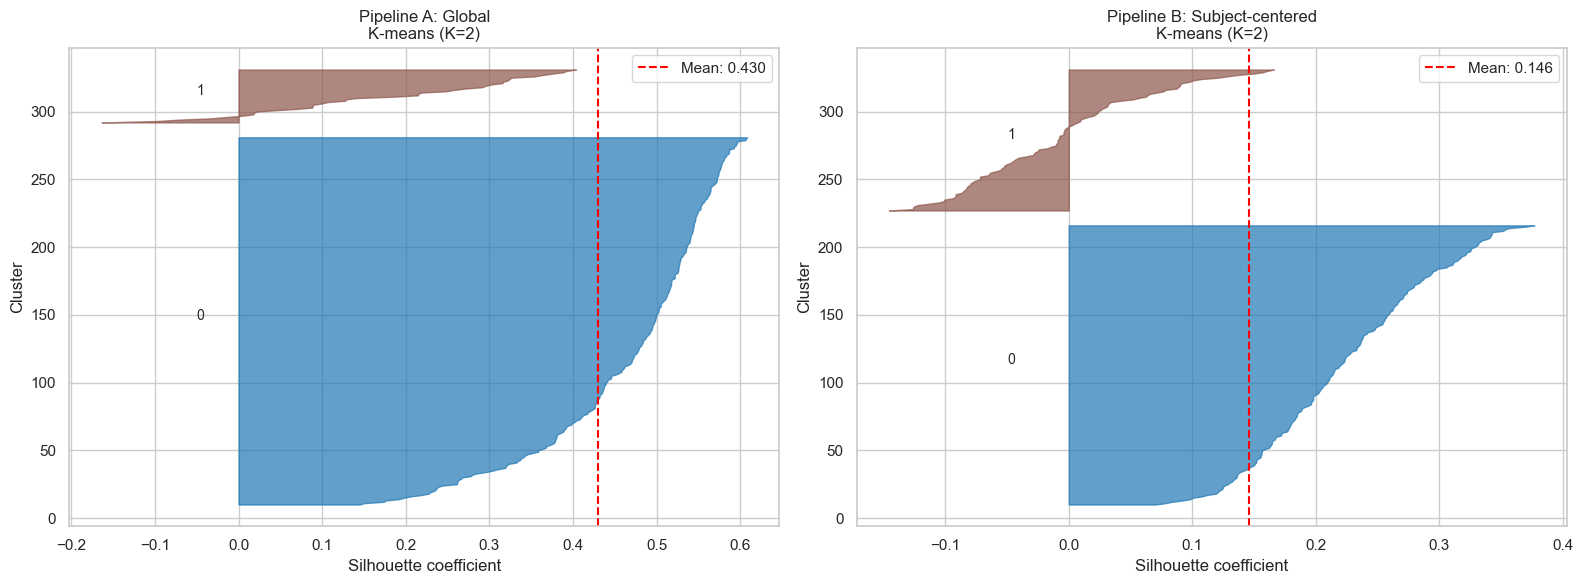

In [ ]:
# Silhouette plots for best K
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, km_results, title in [
    (axes[0], km_global, "Pipeline A: Global"),
    (axes[1], km_centered, "Pipeline B: Subject-centered"),
]:
    best = select_best_k(km_results, criterion="silhouette")
    sample_sils = best.silhouette_samples
    labels = best.labels
    n_clusters = best.k

    y_lower = 10
    for i in range(n_clusters):
        cluster_sils = sample_sils[labels == i]
        cluster_sils.sort()
        size = cluster_sils.shape[0]
        y_upper = y_lower + size

        color = plt.cm.tab10(i / n_clusters)
        ax.fill_betweenx(
            np.arange(y_lower, y_upper), 0, cluster_sils,
            facecolor=color, edgecolor=color, alpha=0.7,
        )
        ax.text(-0.05, y_lower + 0.5 * size, str(i), fontsize=10)
        y_lower = y_upper + 10

    ax.axvline(x=best.silhouette, color="red", linestyle="--",
               label=f"Mean: {best.silhouette:.3f}")
    ax.set_xlabel("Silhouette coefficient")
    ax.set_ylabel("Cluster")
    ax.set_title(f"{title}\nK-means (K={best.k})")
    ax.legend()

plt.tight_layout()
plt.savefig(RESULTS_DIR / "silhouette_plots.png", dpi=150, bbox_inches="tight")
plt.show()

#### visualizing clusters in PCA space

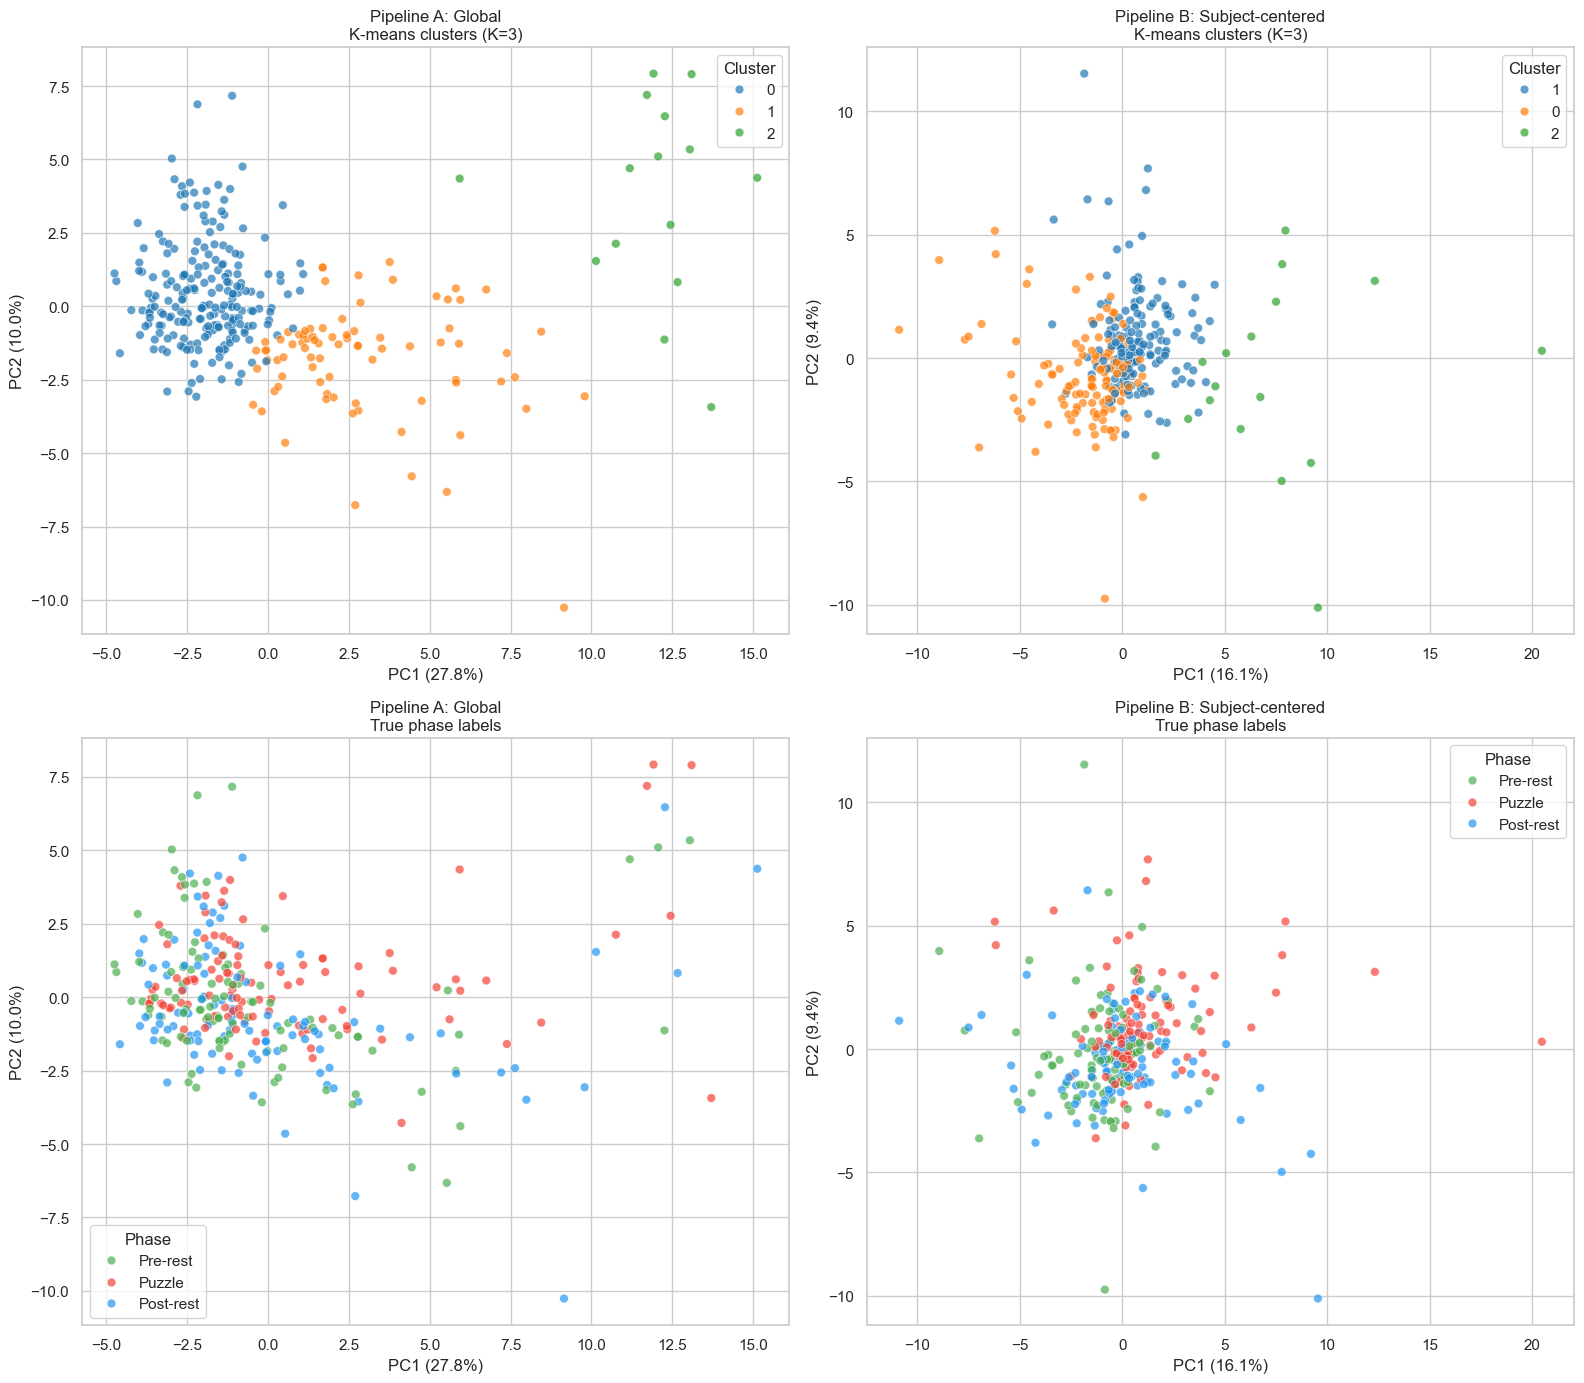

In [12]:
fig, axes = plt.subplots(2, 2, figsize=(16, 14))

for col, (pca_result, km_results, title) in enumerate([
    (pca_global, km_global, "Pipeline A: Global"),
    (pca_centered, km_centered, "Pipeline B: Subject-centered"),
]):
    km_k3 = [r for r in km_results if r.k == 3][0]

    var1 = pca_result.explained_variance_ratio[0]
    var2 = pca_result.explained_variance_ratio[1]

    # top row: colored by cluster
    ax = axes[0, col]
    scatter_df = pd.DataFrame({
        "PC1": pca_result.scores[:, 0],
        "PC2": pca_result.scores[:, 1],
        "Cluster": km_k3.labels.astype(str),
    })
    sns.scatterplot(
        data=scatter_df, x="PC1", y="PC2", hue="Cluster",
        palette="tab10", alpha=0.7, s=40, ax=ax,
    )
    ax.set_xlabel(f"PC1 ({var1:.1%})")
    ax.set_ylabel(f"PC2 ({var2:.1%})")
    ax.set_title(f"{title}\nK-means clusters (K=3)")

    # bottom row: colored by phase (for comparison)
    ax = axes[1, col]
    scatter_df = pd.DataFrame({
        "PC1": pca_result.scores[:, 0],
        "PC2": pca_result.scores[:, 1],
        "Phase": phase_display,
    })
    sns.scatterplot(
        data=scatter_df, x="PC1", y="PC2", hue="Phase",
        hue_order=["Pre-rest", "Puzzle", "Post-rest"],
        palette={"Pre-rest": "#4CAF50", "Puzzle": "#F44336", "Post-rest": "#2196F3"},
        alpha=0.7, s=40, ax=ax,
    )
    ax.set_xlabel(f"PC1 ({var1:.1%})")
    ax.set_ylabel(f"PC2 ({var2:.1%})")
    ax.set_title(f"{title}\nTrue phase labels")

plt.tight_layout()
plt.savefig(RESULTS_DIR / "clusters_vs_phases_pca.png", dpi=150, bbox_inches="tight")
plt.show()

In [16]:
print("=" * 70)
print("More about what clusteres capture")
print("=" * 70)

for pipeline_name, km_results in [
    ("A: Global", km_global),
    ("B: Subject-centered", km_centered),
]:
    km_k3 = [r for r in km_results if r.k == 3][0]

    print(f"\n{'='*70}")
    print(f"  {pipeline_name} — K-means K=3")
    print(f"{'='*70}")

    # vs Phase
    ct_phase = pd.crosstab(km_k3.labels, phase_display, margins=True)
    print(f"\n  Clusters vs Phase:")
    print(ct_phase)

    # vs Individual (top contributors per cluster)
    print(f"\n  Clusters vs Individual:")
    ct_ind = pd.crosstab(km_k3.labels, meta["Individual"].values)
    for cluster_id in range(3):
        top_individuals = ct_ind.loc[cluster_id].sort_values(ascending=False).head(5)
        print(f"    Cluster {cluster_id}: top individuals = "
              f"{dict(top_individuals)}")

    # vs Role
    ct_role = pd.crosstab(km_k3.labels, puzzler_labels, margins=True)
    print(f"\n  Clusters vs Role:")
    print(ct_role)

More about what clusteres capture

  A: Global — K-means K=3

  Clusters vs Phase:
col_0  Post-rest  Pre-rest  Puzzle  All
row_0                                  
0             71        75      70  216
1             29        25      27   81
2              4         4       7   15
All          104       104     104  312

  Clusters vs Individual:
    Cluster 0: top individuals = {1: np.int64(12), 3: np.int64(12), 9: np.int64(12), 10: np.int64(12), 8: np.int64(12)}
    Cluster 1: top individuals = {15: np.int64(12), 16: np.int64(12), 17: np.int64(11), 18: np.int64(11), 20: np.int64(11)}
    Cluster 2: top individuals = {19: np.int64(12), 17: np.int64(1), 18: np.int64(1), 20: np.int64(1), 5: np.int64(0)}

  Clusters vs Role:
col_0  Instructor  Puzzler  All
row_0                          
0             108      108  216
1              46       35   81
2               2       13   15
All           156      156  312

  B: Subject-centered — K-means K=3

  Clusters vs Phase:
col_0  Post-res

In [18]:
# evaluate clusters vs individual

from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score
# ARI/NMI vs Individual labels
print("=" * 70)
print("CLUSTER ALIGNMENT: PHASE vs INDIVIDUAL")
print("=" * 70)

comparison_rows = []

for pipeline_name, km_results in [
    ("A: Global", km_global),
    ("B: Subject-centered", km_centered),
]:
    for r in km_results:
        ari_phase = adjusted_rand_score(y, r.labels)
        nmi_phase = normalized_mutual_info_score(y, r.labels)
        ari_indiv = adjusted_rand_score(meta["Individual"].values, r.labels)
        nmi_indiv = normalized_mutual_info_score(meta["Individual"].values, r.labels)

        comparison_rows.append({
            "Pipeline": pipeline_name,
            "K": r.k,
            "ARI_phase": f"{ari_phase:.3f}",
            "NMI_phase": f"{nmi_phase:.3f}",
            "ARI_individual": f"{ari_indiv:.3f}",
            "NMI_individual": f"{nmi_indiv:.3f}",
        })



comp_df = pd.DataFrame(comparison_rows)
print(comp_df.to_string(index=False))

CLUSTER ALIGNMENT: PHASE vs INDIVIDUAL
           Pipeline  K ARI_phase NMI_phase ARI_individual NMI_individual
          A: Global  2    -0.000     0.004          0.012          0.134
          A: Global  3    -0.003     0.003          0.047          0.306
          A: Global  4    -0.000     0.008          0.073          0.330
          A: Global  5    -0.003     0.005          0.074          0.344
          A: Global  6    -0.000     0.017          0.084          0.380
B: Subject-centered  2     0.041     0.045         -0.002          0.014
B: Subject-centered  3     0.078     0.076         -0.001          0.048
B: Subject-centered  4     0.048     0.049         -0.000          0.069
B: Subject-centered  5     0.023     0.042         -0.000          0.087
B: Subject-centered  6     0.023     0.041          0.009          0.140


Pipeline A (Global):
- ARI_individual: 0.012 to 0.084 (increases with K, clusters track individuals)
- NMI_individual: 0.134 to 0.380 (STRONG individual alignment)
- ARI_phase: ~0.000 (No phase alignment at any K)

Pipeline B (Subject-centered):
- ARI_individual: ~0.000 (individual alignment eliminated)
- NMI_individual: 0.014 to 0.140 (much weaker, only at high K)
- ARI_phase: peaks at 0.078 for K=3 (WEAK but present phase alignment)

**Conclusion:** This table is the evidence for the value of subject-centering. 
In Pipeline A, unsupervised clustering recovers individual identity (NMI up to 0.38) 
but completely ignores phase. In Pipeline B, individual structure is removed and a weak 
but real phase signal emerges (ARI=0.078). The physiological effect of the puzzle task 
exists but is an order of magnitude smaller than inter-subject variability.

In [19]:
# evaluating all for saving
all_km_evals_global = [evaluate_clustering(r, y, phase_names) for r in km_global]
all_km_evals_centered = [evaluate_clustering(r, y, phase_names) for r in km_centered]

paths_global = save_clustering_results(
    km_global, all_km_evals_global, meta, RESULTS_DIR, prefix="km_global"
)
paths_centered = save_clustering_results(
    km_centered, all_km_evals_centered, meta, RESULTS_DIR, prefix="km_centered"
)

print("Saved clustering results:")
for k, v in paths_global.items():
    print(f"  Global {k}: {v}")
for k, v in paths_centered.items():
    print(f"  Centered {k}: {v}")

Saved clustering results:
  Global summary: C:\Users\PJS\ComputationalDataAnalysis\02582_Case2_Group-2\results\clustering\km_global_summary.csv
  Global labels: C:\Users\PJS\ComputationalDataAnalysis\02582_Case2_Group-2\results\clustering\km_global_best_labels.csv
  Centered summary: C:\Users\PJS\ComputationalDataAnalysis\02582_Case2_Group-2\results\clustering\km_centered_summary.csv
  Centered labels: C:\Users\PJS\ComputationalDataAnalysis\02582_Case2_Group-2\results\clustering\km_centered_best_labels.csv
